# 3. Data Preparation

Terceira fase do CRISP-DM. O que entra aqui é o CSV bruto carregado direto de `data/raw/`; o que sai é um dataset processado, pronto para a EDA do notebook 04. Esta fase é menos sobre análise e mais sobre decisões de representação: como categorizar a target, que tipos de coluna usar, se vamos transformar variáveis assimétricas, e como garantir que tudo seja reprodutível.

A regra que sigo aqui é "transformações idempotentes e auditáveis": cada passo é determinístico, e o dataset processado pode ser regenerado a qualquer hora rodando o notebook do zero.

## 3.1 Carregamento e setup

A partir desta fase, o mesmo dataset vai aparecer em quatro notebooks seguidos (03 prep, 04 EDA, 05 regressão, 06 classificação). Para evitar duplicar a função de carregamento em cada um, criei um módulo reutilizável em `src/nps/data.py` com a função `carregar_dataset_bruto()`.

### Sobre como importar código de `src/` no notebook

Existem dois caminhos comuns para um notebook usar um módulo Python que mora em outro diretório do projeto. Vale entender os dois antes de escolher um.

**Caminho 1: pacote instalado em modo editável (o que vamos usar)**

```python
from nps.data import carregar_dataset_bruto
```

Funciona porque o `pyproject.toml` declara `src/nps` como um pacote empacotável (via hatch), e o `uv sync` instala esse pacote dentro da virtualenv apontando para o código-fonte real (modo editável). Resultado: qualquer arquivo dentro do `.venv` consegue importar `nps` como se fosse uma biblioteca de terceiro, e mudanças no código de `src/nps/` aparecem imediatamente.

**Caminho 2: manipulação de `sys.path` no notebook**

```python
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
from nps.data import carregar_dataset_bruto
```

Essa é a forma mais explícita: o notebook diz literalmente "adicione `../src` à lista de lugares onde Python procura módulos". É útil em projetos sem `pyproject.toml` ou em ambientes restritos onde não se pode instalar pacote local.

### Tradeoffs entre os dois caminhos

| Aspecto | Pacote instalado | sys.path |
|---|---|---|
| Verbosidade no notebook | Mínima (uma linha) | 3-4 linhas de boilerplate |
| Setup inicial | Exige `pyproject.toml` correto e `uv sync` | Funciona sem nada extra |
| Funciona em scripts e testes | Sim | Só onde o `sys.path` foi configurado |
| Ferramentas de IDE (autocomplete, type-checker) | Funcionam bem | Geralmente confusas |
| Risco de "import quebrado" ao mexer em paths | Baixo | Alto (depende do `cwd`) |
| Prática profissional | Padrão da indústria | Comum em didática e scripts ad-hoc |

Vou seguir com o caminho 1 porque o projeto já está configurado para isso, e porque toda evolução adiante (testes, pipeline, scripts) vai se beneficiar do mesmo import limpo. O caminho 2 fica como referência para quando aparecer um projeto onde não dá para instalar pacote local.

In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Funcao do nosso modulo (definida em src/nps/data.py)
from nps.data import carregar_dataset_bruto

# Reprodutibilidade
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuracao visual padrao
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Caminhos para esse notebook (figuras desta fase)
RAIZ_PROJETO = Path.cwd().parent
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "03_data_preparation"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Pasta de saida do dataset processado
PASTA_DADOS_PROCESSADOS = RAIZ_PROJETO / "data" / "processed"
PASTA_DADOS_PROCESSADOS.mkdir(parents=True, exist_ok=True)

# Carregamento do dataset bruto via funcao do modulo
dados = carregar_dataset_bruto()

print(f"Dataset carregado: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")

Dataset carregado: 2,500 linhas x 19 colunas


A partir daqui, `dados` contém o CSV bruto exatamente como está em `data/raw/`. As próximas seções vão derivar variáveis novas e gerar o dataset processado em `data/processed/`. Importante: as transformações que fizermos aqui **não modificam** `data/raw/`. Em projetos de DS, o diretório `raw/` deve ser sempre tratado como imutável.

## 3.2 Categorização canônica do NPS

A primeira variável derivada que vamos criar é a `categoria_nps`, que traduz o `nps_score` (0.0 a 10.0 em float) para os três buckets canônicos do NPS: detrator, neutro e promotor. Essa coluna é o que vamos usar como target na fase de classificação (notebook 06), e também serve para segmentar gráficos por bucket no notebook 04.

### Por que vetorizar essa transformação no módulo?

A função foi extraída para `src/nps/features.py` em vez de ficar inline no notebook. Três razões para essa escolha:

- **Reutilização:** a mesma classificação vai aparecer no notebook 04 (segmentar EDA por bucket), no 06 (treinar classificador) e nos slides. Manter em um único lugar evita divergência entre notebooks.
- **Performance:** a versão vetorizada usa `pd.cut`, que é nativo do pandas e roda em C por baixo dos panos. Bem mais rápido que aplicar a função escalar via `.apply()` em cada linha. Para 2.500 linhas a diferença é imperceptível, mas é a escolha certa para um projeto que pode escalar depois.
- **Testabilidade:** com a função em módulo, dá para escrever teste unitário simples (em `tests/test_features.py`) confirmando que 6.9 vai para detrator, 7.0 para neutro, e 9.0 para promotor. É a forma de garantir que mudanças futuras não quebram a regra canônica.

### Constantes nomeadas em vez de números soltos

No módulo, defini `CORTE_DETRATOR_NEUTRO = 7` e `CORTE_NEUTRO_PROMOTOR = 9` em vez de espalhar os números 7 e 9 pelo código. Isso é uma prática simples mas valiosa: se um dia a empresa decidir adotar uma régua diferente (alguns NPS internos usam 0-6 detrator e 7-10 promotor sem neutro, por exemplo), basta mudar a constante em um lugar.

In [2]:
from nps.features import adicionar_categoria_nps, CATEGORIAS_NPS_ORDEM

# Adiciona a coluna categoria_nps usando a funcao do modulo
dados = adicionar_categoria_nps(dados)

# Confirma o tipo da coluna criada
print("Tipo da coluna criada:", dados["categoria_nps"].dtype)
print("Ordenada?", dados["categoria_nps"].cat.ordered)
print("Categorias na ordem definida:", list(dados["categoria_nps"].cat.categories))
print()

# Confirma a distribuicao (mesmo resultado que vimos no notebook 02)
print("Distribuicao da nova coluna:")
print(dados["categoria_nps"].value_counts().reindex(list(CATEGORIAS_NPS_ORDEM)))

Tipo da coluna criada: category
Ordenada? True
Categorias na ordem definida: ['detrator', 'neutro', 'promotor']

Distribuicao da nova coluna:
categoria_nps
detrator    2109
neutro       281
promotor     110
Name: count, dtype: int64


A coluna foi criada com sucesso, do tipo `category` ordenada (detrator < neutro < promotor). A distribuição (2109 / 281 / 110) bate exatamente com o que vimos no notebook 02, confirmando que a categorização do módulo segue a regra canônica.

O dataset agora tem 20 colunas (19 originais + a nova `categoria_nps`). O `nps_score` continua intacto na sua representação contínua, então temos as duas formas disponíveis para as próximas fases: regressão na escala 0 a 10 e classificação nos três buckets.

In [3]:
# Sanidade: o dataset tem mais uma coluna agora
print(f"Shape atual: {dados.shape}")
print(f"Colunas adicionadas em relacao ao bruto: {[c for c in dados.columns if c not in carregar_dataset_bruto().columns]}")

Shape atual: (2500, 20)
Colunas adicionadas em relacao ao bruto: ['categoria_nps']


A categorização está pronta. As próximas seções vão tratar das outras transformações (categorical para `customer_region`, avaliação de log para variáveis assimétricas, etc) antes de salvar o dataset processado.

## 3.3 Conversão de `customer_region` para Categorical

A coluna `customer_region` veio como string (cinco valores possíveis: Sul, Sudeste, Norte, Nordeste, Centro-Oeste). Pandas oferece um tipo dedicado para esse tipo de variável: `Categorical`. Vale fazer essa conversão agora, antes de seguir.

A vantagem prática é dupla. Em **memória**, uma coluna `Categorical` armazena os valores únicos em uma tabela interna e nas linhas guarda apenas um índice inteiro (1 byte se houver até 256 categorias), em vez de uma string completa. Em **operações**, comparações ficam mais rápidas porque comparar inteiros é mais barato que comparar strings.

### Decisão sobre ordenação

`Categorical` pode ser ordenado ou não. A `categoria_nps` que criamos na 3.2 é ordenada (detrator < neutro < promotor) porque há uma noção natural de "pior" para "melhor". As regiões do Brasil **não** têm ordem natural: Sul não é "maior" que Sudeste em nenhum sentido analítico. Vou criar a coluna como `Categorical` não-ordenada (`ordered=False`, que é o padrão), o que é correto semanticamente e evita comparações sem sentido em código futuro.

In [4]:
# Mede memoria antes da conversao
memoria_antes = dados["customer_region"].memory_usage(deep=True)

# Conversao para Categorical nao-ordenado
dados["customer_region"] = dados["customer_region"].astype("category")

# Mede memoria depois
memoria_depois = dados["customer_region"].memory_usage(deep=True)
reducao_pct = (1 - memoria_depois / memoria_antes) * 100

# Confirma a conversao
print(f"Tipo apos conversao: {dados['customer_region'].dtype}")
print(f"Categorias: {list(dados['customer_region'].cat.categories)}")
print(f"Ordenada? {dados['customer_region'].cat.ordered}")
print()
print(f"Memoria da coluna antes:  {memoria_antes:>10,} bytes ({memoria_antes/1024:>6.1f} KB)")
print(f"Memoria da coluna depois: {memoria_depois:>10,} bytes ({memoria_depois/1024:>6.1f} KB)")
print(f"Reducao: {reducao_pct:.1f}%")

Tipo apos conversao: category
Categorias: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
Ordenada? False

Memoria da coluna antes:     139,861 bytes ( 136.6 KB)
Memoria da coluna depois:      2,912 bytes (   2.8 KB)
Reducao: 97.9%


A conversão reduziu o uso de memória da coluna em quase 98% (de 136 KB para 2,8 KB). O ganho é tão alto porque a coluna tem 2.500 strings repetidas em apenas cinco valores possíveis: o `Categorical` armazena os cinco valores uma vez só e usa códigos inteiros nas linhas.

Em datasets pequenos como o nosso, o ganho absoluto é insignificante (a base inteira ainda cabe em meio MB). Mas em datasets reais com milhões de linhas, esse tipo de conversão pode ser a diferença entre um pipeline que roda em 30 segundos e outro que roda em 5 minutos. A boa prática é converter para `Categorical` toda variável de baixa cardinalidade tão cedo quanto possível na pipeline.

## 3.4 Avaliação de transformação log para variáveis assimétricas

A análise da seção 2.5 mostrou que duas variáveis do pedido têm distribuição **assimétrica à direita** (mais conhecida como *right-skewed* ou *positively skewed*): `order_value` e `discount_value`. Em ambas, a maior parte dos valores está concentrada nas faixas mais baixas, com cauda longa se estendendo até valores altos.

Distribuições assimétricas são comuns em variáveis monetárias, mas trazem dois problemas para regressão linear:

- **Erros do modelo concentrados na cauda:** quando uma variável tem cauda longa, os erros da regressão tendem a ficar muito maiores na ponta da distribuição do que no meio. A regressão linear funciona melhor quando os erros são parecidos em toda a faixa de valores, então cauda longa atrapalha o ajuste.
- **Sensibilidade a valores extremos:** poucos pedidos de ticket muito alto podem dominar o ajuste e mascarar a relação real para a maioria dos clientes.

A solução clássica para reduzir esse tipo de assimetria é aplicar uma **transformação logarítmica**, que comprime a cauda e aproxima a distribuição de uma forma mais simétrica.

### Por que `log1p` em vez de `log`

Vou usar `np.log1p`, que calcula `log(1 + x)` em vez de `log(x)` puro. Três motivos:

- **Estabilidade numérica em zero:** `log(0)` é menos infinito; `log1p(0)` é zero. A coluna `discount_value` tem mínimo 0.02, ou seja, próximo de zero. Em datasets reais com zero exato (cliente sem desconto), `log1p` evita erro.
- **Mesma forma assintótica:** para valores não muito pequenos, `log1p(x)` é praticamente igual a `log(x)`. A diferença só importa perto de zero.
- **Reversibilidade exata:** `np.expm1(log1p(x))` retorna o valor original com precisão de máquina, útil quando precisamos voltar à escala em R$ para apresentação.

### Como vou avaliar o ganho

Para confirmar que a transformação está fazendo o que se espera, vou olhar duas coisas para cada variável: o **histograma antes e depois**, e o **coeficiente de assimetria (skewness)** calculado por `pd.Series.skew()`. Skewness próxima de zero indica distribuição simétrica; valores positivos indicam cauda à direita; quanto maior em módulo, mais assimétrica.

Skewness de order_value:
  original:  1.270
  log1p:    -0.689
  reducao em modulo: 0.582


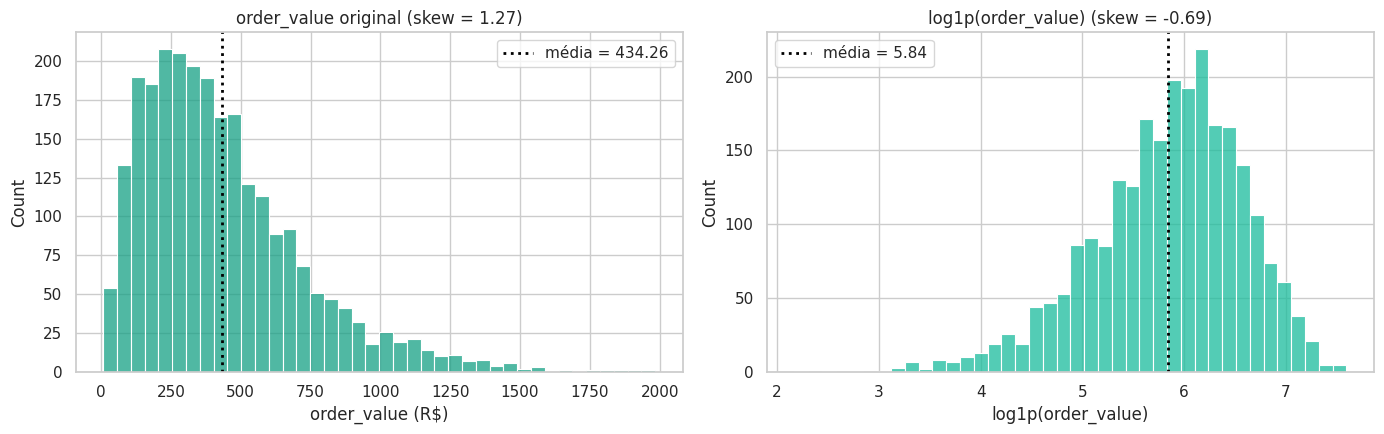

In [5]:
import numpy as np

# Compara order_value original vs log1p
serie_orig = dados["order_value"]
serie_log = np.log1p(serie_orig)

skew_orig = serie_orig.skew()
skew_log = serie_log.skew()

print(f"Skewness de order_value:")
print(f"  original: {skew_orig:>6.3f}")
print(f"  log1p:    {skew_log:>6.3f}")
print(f"  reducao em modulo: {abs(skew_orig) - abs(skew_log):.3f}")

# Histogramas lado a lado, com linha de media em cada
fig, eixos = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(serie_orig, bins=40, ax=eixos[0], color="#16a085", edgecolor="white")
media_orig = serie_orig.mean()
eixos[0].axvline(media_orig, color="black", linestyle=":", linewidth=2, label=f"média = {media_orig:.2f}")
eixos[0].set_title(f"order_value original (skew = {skew_orig:.2f})")
eixos[0].set_xlabel("order_value (R$)")
eixos[0].legend()

sns.histplot(serie_log, bins=40, ax=eixos[1], color="#1abc9c", edgecolor="white")
media_log = serie_log.mean()
eixos[1].axvline(media_log, color="black", linestyle=":", linewidth=2, label=f"média = {media_log:.2f}")
eixos[1].set_title(f"log1p(order_value) (skew = {skew_log:.2f})")
eixos[1].set_xlabel("log1p(order_value)")
eixos[1].legend()

fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "3_4_log_order_value.png", dpi=120, bbox_inches="tight")
plt.show()

![Comparativo de order_value original vs log1p](../reports/figures/03_data_preparation/3_4_log_order_value.png)

**Como ler este gráfico:** dois histogramas lado a lado, comparando a mesma variável antes e depois da transformação logarítmica (`log1p`). À esquerda, distribuição original em reais com forte cauda à direita; à direita, mesma variável após `log1p`, com forma mais simétrica. O **valor de skew anotado no título** quantifica a assimetria: quanto mais próximo de zero, mais simétrica a distribuição. A **linha pontilhada preta** marca a média em cada painel.

A transformação reduziu a assimetria de `order_value` de forma clara: o skew original é positivo (cauda à direita) e cai bastante após o log1p, ficando mais próximo de uma distribuição simétrica. Visualmente, o histograma da direita está bem mais "centrado" e arredondado, enquanto o da esquerda tinha uma cauda longa de pedidos de ticket alto.

Isso significa que, para regressão linear no notebook 05, vai fazer sentido usar `log1p(order_value)` como variável de entrada em vez do valor cru. Para apresentação executiva e estatística descritiva, mantemos a coluna original em reais.

Skewness de discount_value:
  original:  1.872
  log1p:    -0.536
  reducao em modulo: 1.336


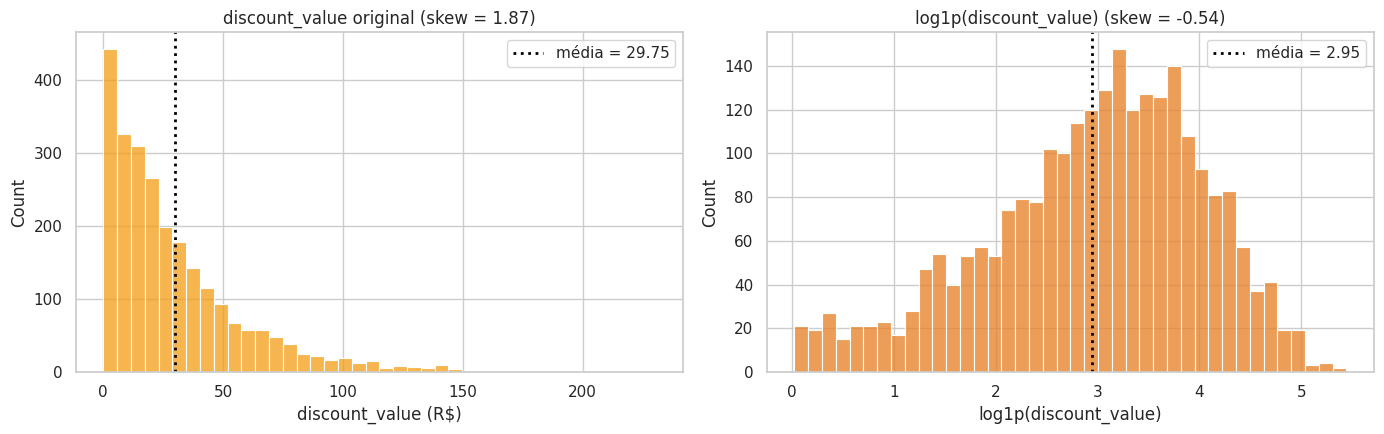

In [6]:
# Compara discount_value original vs log1p
serie_orig = dados["discount_value"]
serie_log = np.log1p(serie_orig)

skew_orig = serie_orig.skew()
skew_log = serie_log.skew()

print(f"Skewness de discount_value:")
print(f"  original: {skew_orig:>6.3f}")
print(f"  log1p:    {skew_log:>6.3f}")
print(f"  reducao em modulo: {abs(skew_orig) - abs(skew_log):.3f}")

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(serie_orig, bins=40, ax=eixos[0], color="#f39c12", edgecolor="white")
media_orig = serie_orig.mean()
eixos[0].axvline(media_orig, color="black", linestyle=":", linewidth=2, label=f"média = {media_orig:.2f}")
eixos[0].set_title(f"discount_value original (skew = {skew_orig:.2f})")
eixos[0].set_xlabel("discount_value (R$)")
eixos[0].legend()

sns.histplot(serie_log, bins=40, ax=eixos[1], color="#e67e22", edgecolor="white")
media_log = serie_log.mean()
eixos[1].axvline(media_log, color="black", linestyle=":", linewidth=2, label=f"média = {media_log:.2f}")
eixos[1].set_title(f"log1p(discount_value) (skew = {skew_log:.2f})")
eixos[1].set_xlabel("log1p(discount_value)")
eixos[1].legend()

fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "3_4_log_discount_value.png", dpi=120, bbox_inches="tight")
plt.show()

![Comparativo de discount_value original vs log1p](../reports/figures/03_data_preparation/3_4_log_discount_value.png)

**Como ler este gráfico:** dois histogramas lado a lado, comparando o `discount_value` antes e depois de `log1p`. À esquerda, original com cauda longa de descontos altos; à direita, versão transformada. O **skew anotado no título** mostra a redução da assimetria. A **linha pontilhada preta** marca a média em cada painel.

Para `discount_value` o efeito da transformação também é positivo, mas com uma característica diferente: a distribuição original já tinha uma forma bastante assimétrica, e o log1p produziu uma versão que, embora mais simétrica, ainda mostra alguma irregularidade. Isso é normal: log nem sempre torna a distribuição perfeitamente normal, mas costuma trazer uma melhora consistente.

A redução de skewness em valor absoluto é menos dramática que a do `order_value`, mas continua sendo suficiente para justificar o uso da versão log na regressão. Como a variável tem valores baixos (mínimo 0,02), o ganho está principalmente em comprimir os poucos clientes com desconto muito alto (acima de R$ 100), que poderiam dominar o ajuste no modelo cru.

### Decisão consolidada

Vou criar duas colunas derivadas no dataset processado: `log_order_value` e `log_discount_value`, mantendo as originais intactas. As colunas log serão usadas como variáveis de entrada na regressão (notebook 05), enquanto as originais ficam disponíveis para análise descritiva e apresentação executiva, onde a leitura em reais é mais clara.

In [7]:
# Criacao das colunas derivadas
dados["log_order_value"] = np.log1p(dados["order_value"])
dados["log_discount_value"] = np.log1p(dados["discount_value"])

# Confirma criacao e mostra estatisticas
print("Colunas log criadas:")
print(dados[["order_value", "log_order_value", "discount_value", "log_discount_value"]].describe().round(3))
print()
print(f"Shape atual: {dados.shape}")

Colunas log criadas:
       order_value  log_order_value  discount_value  log_discount_value
count     2500.000         2500.000        2500.000            2500.000
mean       434.260            5.837          29.746               2.948
std        289.772            0.746          29.226               1.082
min          7.760            2.170           0.020               0.020
25%        220.245            5.399           8.885               2.291
50%        375.515            5.931          20.935               3.088
75%        577.290            6.360          40.832               3.734
max       1983.810            7.593         230.330               5.444

Shape atual: (2500, 22)


As duas colunas log foram criadas com sucesso. O dataset agora tem 22 colunas (19 originais + `categoria_nps` + `log_order_value` + `log_discount_value`). A próxima seção fecha as decisões sobre o `csat_internal_score` antes de seguir para o salvamento do dataset processado.

## 3.5 Decisão sobre `csat_internal_score`

Esta seção fecha uma decisão importante que vinha sendo discutida desde a Fase 1: o que fazer com o `csat_internal_score` quando formos treinar o modelo. A coluna fica no dataset processado normalmente, mas a decisão real sobre incluí-la ou não no modelo é feita no notebook 05, e vale registrar agora qual é o critério para essa escolha.

### O risco do "atalho"

O `csat_internal_score` é um score calculado pela própria empresa, e como vimos na seção 2.7 ele caminha praticamente junto com o NPS (separação muito clara entre detratores, neutros e promotores também no CSAT). É bem provável que esse score seja calculado a partir das mesmas variáveis operacionais que estamos usando como entrada do modelo: tempo de entrega, atraso, contatos com SAC, e por aí vai.

Se for esse o caso, incluir o `csat_internal_score` como variável de entrada cria um problema: o modelo pode acabar "aprendendo um atalho", ou seja, em vez de aprender como cada variável operacional individualmente afeta o NPS, ele apenas se ancora no CSAT (que já é um resumo dessas variáveis) e copia a nota para fora. O resultado parece ótimo no treino, mas em produção o modelo pode não conseguir explicar o **porquê** da detração, e essa explicação é exatamente o que o negócio precisa para agir.

### Estratégia adotada

Vou tomar uma abordagem prática que evita decidir sem dados: na fase de modelagem (notebook 05) vamos rodar **dois modelos paralelos**, com a mesma base e os mesmos parâmetros, mudando apenas a inclusão do `csat_internal_score`.

- **Modelo A:** com `csat_internal_score` incluído como variável de entrada.
- **Modelo B:** sem `csat_internal_score`, usando apenas as variáveis operacionais cruas.

Comparando o desempenho dos dois, vamos conseguir responder a três perguntas que importam para o negócio:

1. Quanto da qualidade do modelo está vindo do CSAT versus das variáveis operacionais?
2. Sem o CSAT, dá para construir um modelo que ainda seja útil para uso prático (priorização de tickets, alarme de detração)?
3. As variáveis que aparecem como mais importantes mudam quando o CSAT é removido?

A decisão de qual modelo usar em produção vai depender dessas respostas. Se o Modelo B tiver desempenho razoável e variáveis interpretáveis, ele provavelmente é a melhor escolha para uso real, mesmo que o Modelo A pareça melhor numericamente. Em projetos de ciência de dados, **interpretabilidade muitas vezes vale mais que precisão pura**, especialmente quando o modelo é usado para apoiar decisão humana.

### O que isso significa para o notebook 03

Nada muda no dataset processado. A coluna `csat_internal_score` continua presente, intacta, exatamente como veio no CSV bruto. A decisão registrada aqui é uma instrução para o notebook 05, que vai usar essa variável de duas formas distintas no momento de treinar os modelos.

## 3.6 Renomeação semântica para a hipótese H5

A hipótese H5, formulada na seção 1.6, diz que o NPS prevê recompra. A variável que sustenta essa hipótese é `repeat_purchase_30d`, binária (0 ou 1). O nome técnico está correto, mas tem um pequeno problema de leitura: à primeira vista pode parecer que é uma contagem de recompras, não um indicador binário.

Para deixar o código dos notebooks 04 e 05 mais claro, vou criar uma cópia da coluna com um nome mais explícito: `houve_recompra_30d`. A coluna original continua intacta no dataset, e a nova é apenas um sinônimo mais legível para uso nas análises da hipótese H5.

Essa transformação é cosmética, mas vale o esforço: nomes claros economizam interpretação ao longo do trabalho, principalmente quando o código vai ser lido em revisão.

In [8]:
# Cria a coluna com nome semanticamente mais claro
dados["houve_recompra_30d"] = dados["repeat_purchase_30d"]

# Confirma que as duas colunas estao identicas e mostra a distribuicao
contagem = dados["houve_recompra_30d"].value_counts().sort_index()
percentual = (contagem / len(dados) * 100).round(1)

print("Distribuicao de houve_recompra_30d:")
for valor, n in contagem.items():
    rotulo = "Sim" if valor == 1 else "Nao"
    print(f"  {valor} ({rotulo}): {n:>5,} clientes ({percentual[valor]}%)")

print()
print(f"Identica a repeat_purchase_30d? {(dados['houve_recompra_30d'] == dados['repeat_purchase_30d']).all()}")
print(f"Shape atual: {dados.shape}")

Distribuicao de houve_recompra_30d:
  0 (Nao): 2,282 clientes (91.3%)
  1 (Sim):   218 clientes (8.7%)

Identica a repeat_purchase_30d? True
Shape atual: (2500, 23)


A coluna foi criada e a distribuição confere com o que vimos no notebook 02 (91,3% sem recompra, 8,7% com recompra). O dataset agora tem 23 colunas, e está praticamente pronto para ser salvo como dataset processado na próxima seção.

## 3.7 Salvamento do dataset processado

Com todas as transformações feitas, é hora de salvar o resultado em `data/processed/`. O dataset processado é o que vai ser carregado pelos próximos notebooks (04 EDA, 05 regressão, 06 classificação), garantindo que todos eles partam do mesmo ponto, sem precisar repetir as transformações.

Para isso, estendi o módulo `src/nps/data.py` com duas funções utilitárias: `salvar_dataset_processado` e `carregar_dataset_processado`. A primeira grava o DataFrame em arquivo, a segunda lê de volta reconstituindo os tipos `Categorical` (que se perdem no formato CSV puro). Os próximos notebooks vão usar a função de carregamento, mantendo o código curto e padronizado.

In [9]:
from nps.data import salvar_dataset_processado

# Salva o dataset processado e mostra o caminho gerado
caminho_processado = salvar_dataset_processado(dados)

print(f"Dataset salvo em: {caminho_processado}")
print(f"Tamanho do arquivo: {caminho_processado.stat().st_size / 1024:.1f} KB")
print(f"Linhas salvas: {len(dados):,}")
print(f"Colunas salvas: {len(dados.columns)}")

Dataset salvo em: /home/cosme/Desktop/path-to-distinguished/ai-scientist-masters/phase-01/tech-challenge/repo/data/processed/dados_processados.csv
Tamanho do arquivo: 409.0 KB
Linhas salvas: 2,500
Colunas salvas: 23


Arquivo gerado. Agora vale confirmar que a leitura de volta funciona como esperado, ou seja, que os tipos `Categorical` são reconstruídos corretamente. É bom validar isso aqui mesmo, antes de seguir para o próximo notebook que vai depender dessa garantia.

In [10]:
from nps.data import carregar_dataset_processado

# Carrega o dataset que acabamos de salvar
dados_recarregados = carregar_dataset_processado()

print(f"Shape recarregado: {dados_recarregados.shape}")
print()
print("Tipos das colunas reconstituidas:")
print(f"  categoria_nps:    {dados_recarregados['categoria_nps'].dtype}")
print(f"  customer_region:  {dados_recarregados['customer_region'].dtype}")
print()
print(f"categoria_nps esta ordenada? {dados_recarregados['categoria_nps'].cat.ordered}")
print(f"Categorias na ordem: {list(dados_recarregados['categoria_nps'].cat.categories)}")
print()

# Verifica integridade: numericas com tolerancia (CSV pode perder bits de precisao
# em alguns casos de borda); categoricas e inteiras com igualdade exata.
colunas_numericas = dados.select_dtypes(include=["float"]).columns
colunas_demais = [c for c in dados.columns if c not in colunas_numericas]

numericas_ok = all(
    np.allclose(dados[c], dados_recarregados[c], rtol=1e-12, atol=1e-12)
    for c in colunas_numericas
)
demais_ok = all(
    (dados[c].astype(str) == dados_recarregados[c].astype(str)).all()
    for c in colunas_demais
)

print(f"Colunas numericas (float) coincidem dentro da tolerancia 1e-12? {numericas_ok}")
print(f"Colunas inteiras e categoricas coincidem exatamente?            {demais_ok}")

Shape recarregado: (2500, 23)

Tipos das colunas reconstituidas:
  categoria_nps:    category
  customer_region:  category

categoria_nps esta ordenada? True
Categorias na ordem: ['detrator', 'neutro', 'promotor']

Colunas numericas (float) coincidem dentro da tolerancia 1e-12? True
Colunas inteiras e categoricas coincidem exatamente?            True


A leitura confirma que os tipos `Categorical` foram reconstituídos corretamente: `categoria_nps` voltou como categórica ordenada (detrator < neutro < promotor) e `customer_region` voltou como categórica não-ordenada.

A verificação foi separada em duas partes por uma razão técnica: o formato CSV não preserva bit-a-bit a representação binária de números float64 (alguns valores como `785.3` podem voltar como `785.2999999999998`, o que é a mesma representação visual mas binariamente um pouco diferente). Para colunas float, usei `np.allclose` com tolerância de 1e-12, que confirma que os valores são iguais dentro da margem de precisão numérica esperada. Para colunas inteiras e categóricas, a comparação exata é apropriada.

O resultado é que o dataset recarregado é, para qualquer fim prático, igual ao que foi salvo. As pequenas diferenças decimais de CSV são imperceptíveis em qualquer análise estatística ou modelo.

A partir daqui, qualquer notebook que precisar dos dados pode simplesmente fazer:

```python
from nps.data import carregar_dataset_processado
dados = carregar_dataset_processado()
```

E vai receber o DataFrame com as 23 colunas e os tipos corretos.

## 3.8 Conclusão da fase

A Fase 3 do CRISP-DM está fechada. O dataset bruto de 19 colunas foi transformado em um dataset processado de 23 colunas, mantendo todas as variáveis originais intactas e adicionando quatro derivadas que vão suportar as análises das próximas fases. O resultado foi salvo em `data/processed/dados_processados.csv` e tem reprodutibilidade garantida pelas funções do módulo `src/nps/data.py`.

Antes de seguir, vale ter uma visão de conjunto do que está no dataset processado, separando as variáveis originais (que vieram do CSV bruto) das derivadas (criadas neste notebook). Isso ajuda a fixar mentalmente o estado do dataset que o notebook 04 vai consumir.

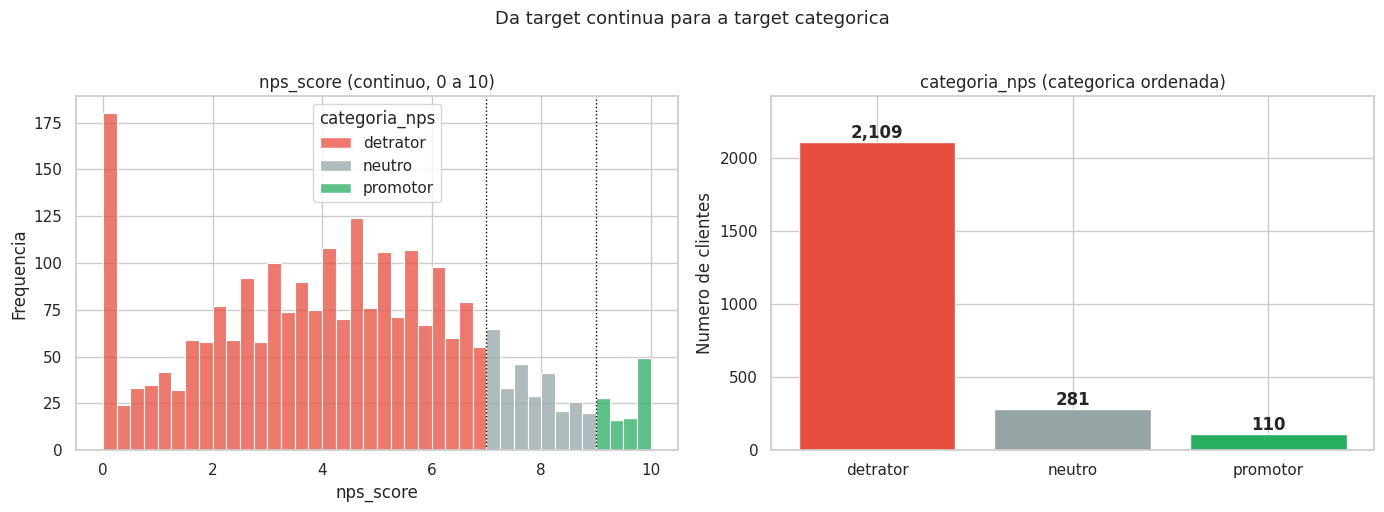

In [11]:
# Visualizacao da transformacao da target: continua (nps_score) -> categorica (categoria_nps)
# Cores semanticas reaproveitadas em todo o trabalho.
cores_buckets = {"detrator": "#e74c3c", "neutro": "#95a5a6", "promotor": "#27ae60"}
ordem_buckets = ["detrator", "neutro", "promotor"]

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

# Esquerda: nps_score continuo, com barras coloridas pela categoria correspondente
sns.histplot(
    data=dados,
    x="nps_score",
    hue="categoria_nps",
    hue_order=ordem_buckets,
    palette=cores_buckets,
    bins=40,
    multiple="stack",
    edgecolor="white",
    ax=eixos[0],
)
eixos[0].axvline(7, color="black", linestyle=":", linewidth=1)
eixos[0].axvline(9, color="black", linestyle=":", linewidth=1)
eixos[0].set_title("nps_score (continuo, 0 a 10)")
eixos[0].set_xlabel("nps_score")
eixos[0].set_ylabel("Frequencia")

# Direita: categoria_nps (bar chart) com a mesma paleta
contagem = dados["categoria_nps"].value_counts().reindex(ordem_buckets)
cores = [cores_buckets[c] for c in ordem_buckets]
eixos[1].bar(ordem_buckets, contagem.values, color=cores, edgecolor="white")
for i, v in enumerate(contagem.values):
    eixos[1].text(i, v + 30, f"{v:,}", ha="center", fontweight="bold")
eixos[1].set_title("categoria_nps (categorica ordenada)")
eixos[1].set_ylabel("Numero de clientes")
eixos[1].set_ylim(0, contagem.max() * 1.15)

fig.suptitle("Da target continua para a target categorica", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "3_8_target_continua_vs_categorica.png", dpi=120, bbox_inches="tight")
plt.show()

![Da target contínua para a target categórica](../reports/figures/03_data_preparation/3_8_target_continua_vs_categorica.png)

**Como ler este gráfico:** dois painéis mostrando as duas representações da mesma target. À esquerda, histograma do `nps_score` (contínuo de 0 a 10), com cada barra **pintada conforme a categoria correspondente** (vermelho = detrator, cinza = neutro, verde = promotor). As **linhas verticais pretas pontilhadas** em 7 e 9 marcam onde uma categoria vira a outra. À direita, a mesma informação como bar chart de três categorias. As duas representações vão ser usadas em momentos diferentes do projeto: o contínuo na regressão, a categórica na classificação.

### Visualizando a transformação da target

O gráfico acima resume a transformação principal deste notebook: o `nps_score` original (contínuo, à esquerda) e a `categoria_nps` derivada (categórica, à direita), pintados com as mesmas cores semânticas que vão ser reaproveitadas nas próximas fases. As linhas verticais pontilhadas no gráfico da esquerda marcam os cortes canônicos (7 e 9), e ajudam a enxergar concretamente como cada faixa do contínuo foi mapeada para um dos três buckets.

Esse gráfico é o que melhor resume o que mudou no dataset. Cada notebook seguinte vai usar uma das duas representações: o notebook 04 (EDA) e o 06 (classificação) trabalham com a categoria à direita, e o notebook 05 (regressão) trabalha com o contínuo à esquerda. As duas vivem no mesmo dataset processado.

### Resumo das transformações aplicadas

Quatro variáveis derivadas foram criadas neste notebook, cada uma com um propósito específico:

| Variável | Tipo | Origem | Para que serve |
|---|---|---|---|
| `categoria_nps` | Categorical ordenada | Função `adicionar_categoria_nps` em `src/nps/features.py`, aplicada sobre `nps_score` | Target da classificação (notebook 06); segmentação de gráficos por bucket no notebook 04 |
| `log_order_value` | float64 | `np.log1p(order_value)` | Variável de entrada na regressão (notebook 05), com cauda comprimida |
| `log_discount_value` | float64 | `np.log1p(discount_value)` | Idem, para `discount_value` |
| `houve_recompra_30d` | int64 | Cópia de `repeat_purchase_30d` | Nome semanticamente claro para a hipótese H5 |

Além das criações, duas conversões de tipo foram aplicadas no DataFrame: `customer_region` virou `Categorical` não-ordenada (economia de memória) e `categoria_nps` virou `Categorical` ordenada (semântica detrator < neutro < promotor).

### O que NÃO foi feito, e por quê

Algumas transformações típicas de Data Preparation não foram aplicadas, e vale registrar a razão:

- **Imputação de missing:** o dataset não tem missing (visto na 2.2). Imputar não faz sentido aqui.
- **Remoção de outliers:** os pontos fora dos bigodes nos boxplots da 2.7 são valores plausíveis (clientes com muitos contatos no SAC, pedidos de ticket alto), não erros de coleta. Remover seria descartar informação real.
- **Encoding de variáveis categóricas:** o tipo `Categorical` do pandas é suficiente para descritivas e visualizações. A escolha entre one-hot, ordinal ou target encoding fica para o notebook 05, dependendo do modelo escolhido.
- **Decisão final sobre `csat_internal_score`:** registrada na 3.5, mas executada como dois modelos paralelos no notebook 05 (com e sem essa variável).

### Próximo passo

O notebook 04 (EDA aprofundada) vai começar carregando o dataset processado direto de `data/processed/`, usando a função do módulo:

```python
from nps.data import carregar_dataset_processado
dados = carregar_dataset_processado()
```

E dali partir para testar estatisticamente as sete hipóteses formuladas no notebook 01. As variáveis derivadas que criamos aqui vão ser referenciadas ao longo dessa análise: `categoria_nps` para segmentação visual, `log_order_value` e `log_discount_value` para checagem de relações, `houve_recompra_30d` para a hipótese H5.